In [7]:
import pandas as pd

path = r"C:\Users\Administrateur\Desktop\JUPYTER\BMW_cleaned_dataset.csv"
df = pd.read_csv(path)

df.head()


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,log_Price_USD,log_Mileage_KM,Vehicle_Age
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,11.500256,11.929983,8
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,11.279984,11.709084,11
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,11.637494,9.304923,2
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,11.018170,10.213029,0
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,10.817756,11.712858,4


In [8]:
# Show basic structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
 11  log_Price_USD         50000 non-null  float64
 12  log_Mileage_KM        50000 non-null  float64
 13  Vehicle_Age           50000 non-null  int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 5.3+ MB


In [9]:
# Show the first 10 rows
df.head(10)


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,log_Price_USD,log_Mileage_KM,Vehicle_Age
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,11.500256,11.929983,8
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,11.279984,11.709084,11
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,11.637494,9.304923,2
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,11.018170,10.213029,0
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,10.817756,11.712858,4
5,5 Series,2017,Middle East,Silver,Diesel,Manual,1.9,171362,42926,1232,Low,10.667256,12.051539,7
6,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,High,10.916270,12.189649,2
7,M5,2014,Asia,Black,Diesel,Automatic,1.6,121156,102778,632,Low,11.540336,11.704843,10
8,X3,2016,South America,White,Diesel,Automatic,1.7,48073,116482,8944,High,11.665501,10.780497,8
9,i8,2019,Europe,White,Electric,Manual,3.0,35700,96257,4411,Low,11.474787,10.482934,5


In [10]:
# Summary statistics for numeric columns 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,50000.0,2017.015700,4.324459,2010.000000,2013.000000,2017.000000,2021.000000,2024.000000
Engine_Size_L,50000.0,3.247180,1.009078,1.500000,2.400000,3.200000,4.100000,5.000000
Mileage_KM,50000.0,100307.203140,57941.509344,3.000000,50178.000000,100388.500000,150630.250000,199996.000000
Price_USD,50000.0,75034.600900,25998.248882,30000.000000,52434.750000,75011.500000,97628.250000,119998.000000
Sales_Volume,50000.0,5067.514680,2856.767125,100.000000,2588.000000,5087.000000,7537.250000,9999.000000
log_Price_USD,50000.0,11.157792,0.382002,10.308986,10.867344,11.225410,11.488932,11.695239
log_Mileage_KM,50000.0,11.207500,1.002797,1.386294,10.823352,11.516813,11.922590,12.206058
Vehicle_Age,50000.0,6.984300,4.324459,0.000000,3.000000,7.000000,11.000000,14.000000


In [11]:
# Summary for categorical columns
df.select_dtypes(include='object').describe().T


,count,unique,top,freq
Model,50000,11,7 Series,4666
Region,50000,6,Asia,8454
Color,50000,6,Red,8463
Fuel_Type,50000,4,Hybrid,12716
Transmission,50000,2,Manual,25154
Sales_Classification,50000,2,Low,34754


In [12]:
# Count duplicates
df.duplicated().sum()


np.int64(0)

In [13]:
# Count missing values
df.isna().sum()


Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
log_Price_USD           0
log_Mileage_KM          0
Vehicle_Age             0
dtype: int64

In [14]:
import pandas as pd
import numpy as np

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Extended percentiles you want
percentiles = [0.01, 0.05, 0.10, 
               0.25, 0.50, 0.75, 
               0.90, 0.95, 0.99]

numeric_summary = df[numeric_cols].describe(percentiles=percentiles).T

numeric_summary


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
Year,50000.0,2017.015700,4.324459,2010.000000,2010.000000,2010.000000,2011.000000,2013.000000,2017.000000,2021.000000,2023.000000,2024.000000,2024.000000,2024.000000
Engine_Size_L,50000.0,3.247180,1.009078,1.500000,1.500000,1.700000,1.900000,2.400000,3.200000,4.100000,4.600000,4.800000,5.000000,5.000000
Mileage_KM,50000.0,100307.203140,57941.509344,3.000000,1947.920000,10013.700000,19972.800000,50178.000000,100388.500000,150630.250000,180525.100000,190219.800000,198047.010000,199996.000000
Price_USD,50000.0,75034.600900,25998.248882,30000.000000,30840.990000,34574.000000,39008.800000,52434.750000,75011.500000,97628.250000,111103.000000,115530.050000,119134.000000,119998.000000
Sales_Volume,50000.0,5067.514680,2856.767125,100.000000,204.000000,597.000000,1086.000000,2588.000000,5087.000000,7537.250000,9018.100000,9510.000000,9897.000000,9999.000000
log_Price_USD,50000.0,11.157792,0.382002,10.308986,10.336632,10.450886,10.571568,10.867344,11.225410,11.488932,11.618222,11.657295,11.688013,11.695239
log_Mileage_KM,50000.0,11.207500,1.002797,1.386294,7.575031,9.211809,9.902177,10.823352,11.516813,11.922590,12.103631,12.155941,12.196265,12.206058
Vehicle_Age,50000.0,6.984300,4.324459,0.000000,0.000000,0.000000,1.000000,3.000000,7.000000,11.000000,13.000000,14.000000,14.000000,14.000000


In [15]:
# 1) numeric columns list
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns:", numeric_cols)

Numeric columns: ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume', 'log_Price_USD', 'log_Mileage_KM', 'Vehicle_Age']


In [16]:
# 2) extended summary with requested percentiles + skew/kurtosis
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
numeric_summary = df[numeric_cols].describe(percentiles=percentiles).T
numeric_summary['skew'] = df[numeric_cols].skew().values
numeric_summary['kurtosis'] = df[numeric_cols].kurtosis().values
print("\nExtended numeric summary:")
display(numeric_summary)


Extended numeric summary:


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,skew,kurtosis
Year,50000.0,2017.015700,4.324459,2010.000000,2010.000000,2010.000000,2011.000000,2013.000000,2017.000000,2021.000000,2023.000000,2024.000000,2024.000000,2024.000000,-0.001496,-1.212287
Engine_Size_L,50000.0,3.247180,1.009078,1.500000,1.500000,1.700000,1.900000,2.400000,3.200000,4.100000,4.600000,4.800000,5.000000,5.000000,-0.001285,-1.196438
Mileage_KM,50000.0,100307.203140,57941.509344,3.000000,1947.920000,10013.700000,19972.800000,50178.000000,100388.500000,150630.250000,180525.100000,190219.800000,198047.010000,199996.000000,-0.006677,-1.205905
Price_USD,50000.0,75034.600900,25998.248882,30000.000000,30840.990000,34574.000000,39008.800000,52434.750000,75011.500000,97628.250000,111103.000000,115530.050000,119134.000000,119998.000000,-0.000034,-1.200754
Sales_Volume,50000.0,5067.514680,2856.767125,100.000000,204.000000,597.000000,1086.000000,2588.000000,5087.000000,7537.250000,9018.100000,9510.000000,9897.000000,9999.000000,-0.012126,-1.196313
log_Price_USD,50000.0,11.157792,0.382002,10.308986,10.336632,10.450886,10.571568,10.867344,11.225410,11.488932,11.618222,11.657295,11.688013,11.695239,-0.476095,-0.883760
log_Mileage_KM,50000.0,11.207500,1.002797,1.386294,7.575031,9.211809,9.902177,10.823352,11.516813,11.922590,12.103631,12.155941,12.196265,12.206058,-1.970498,5.565849
Vehicle_Age,50000.0,6.984300,4.324459,0.000000,0.000000,0.000000,1.000000,3.000000,7.000000,11.000000,13.000000,14.000000,14.000000,14.000000,0.001496,-1.212287


In [17]:

# 3) Outlier diagnostics: IQR bounds, counts below 1%/above 99%, IQR outliers, z-score>3
outlier_rows = []
for col in numeric_cols:
    col_data = df[col].dropna()
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    n_below_1pct = (col_data < col_data.quantile(0.01)).sum()
    n_above_99pct = (col_data > col_data.quantile(0.99)).sum()
    n_below_lower_iqr = (col_data < lower_iqr).sum()
    n_above_upper_iqr = (col_data > upper_iqr).sum()
    mean = col_data.mean()
    std = col_data.std(ddof=0)
    if std == 0 or np.isnan(std):
        n_z_gt3 = 0
    else:
        z = (col_data - mean) / std
        n_z_gt3 = (z.abs() > 3).sum()
    outlier_rows.append({
        'column': col,
        'count': int(len(col_data)),
        'n_below_1pct': int(n_below_1pct),
        'n_above_99pct': int(n_above_99pct),
        'n_below_lower_iqr': int(n_below_lower_iqr),
        'n_above_upper_iqr': int(n_above_upper_iqr),
        'n_zscore_gt3': int(n_z_gt3),
        'lower_iqr': float(lower_iqr),
        'upper_iqr': float(upper_iqr)
    })

outlier_df = pd.DataFrame(outlier_rows).set_index('column')
print("\nOutlier diagnostics:")
display(outlier_df)


Outlier diagnostics:


,count,n_below_1pct,n_above_99pct,n_below_lower_iqr,n_above_upper_iqr,n_zscore_gt3,lower_iqr,upper_iqr
column,,,,,,,,
Year,50000,0,0,0,0,0,2001.000000,2033.000000
Engine_Size_L,50000,0,0,0,0,0,-0.150000,6.650000
Mileage_KM,50000,500,500,0,0,0,-100500.375000,301308.625000
Price_USD,50000,500,499,0,0,0,-15355.500000,165418.500000
Sales_Volume,50000,498,497,0,0,0,-4835.875000,14961.125000
log_Price_USD,50000,500,499,0,0,0,9.934961,12.421315
log_Mileage_KM,50000,500,500,2414,0,935,9.174495,13.571447
Vehicle_Age,50000,0,0,0,0,0,-9.000000,23.000000


In [20]:
# --- 1. Shows first/last rows and all columns to inspect structure.
# Set pandas option to display all columns
pd.set_option('display.max_columns', None)
print("--- First 5 Rows ---")
print(df.head())
print("\n--- Last 5 Rows ---")
print(df.tail())

--- First 5 Rows ---
      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  log_Price_USD  \
0      151748      98740          8300                 High      11.500256   
1      121671      79219          3428                  Low      11.279984   
2       10991     113265          6994                  Low      11.637494   
3       27255      60971          4047                  Low      11.018170   
4      122131      49898          3080                  Low      10.817756   

   log_Mileage_KM  Vehi

In [21]:
# --- 2. Displays missing values to confirm cleaning.
print("\n--- Missing Value Check (Sum per column) ---")
print(df.isnull().sum())


--- Missing Value Check (Sum per column) ---
Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
log_Price_USD           0
log_Mileage_KM          0
Vehicle_Age             0
dtype: int64


In [22]:
# --- 3. Numeric summary + percentiles to detect unusual distributions.
print("\n--- Numeric Summary and Percentiles ---")
print(df.describe())


--- Numeric Summary and Percentiles ---
               Year  Engine_Size_L     Mileage_KM      Price_USD  \
count  50000.000000   50000.000000   50000.000000   50000.000000   
mean    2017.015700       3.247180  100307.203140   75034.600900   
std        4.324459       1.009078   57941.509344   25998.248882   
min     2010.000000       1.500000       3.000000   30000.000000   
25%     2013.000000       2.400000   50178.000000   52434.750000   
50%     2017.000000       3.200000  100388.500000   75011.500000   
75%     2021.000000       4.100000  150630.250000   97628.250000   
max     2024.000000       5.000000  199996.000000  119998.000000   

       Sales_Volume  log_Price_USD  log_Mileage_KM   Vehicle_Age  
count  50000.000000   50000.000000    50000.000000  50000.000000  
mean    5067.514680      11.157792       11.207500      6.984300  
std     2856.767125       0.382002        1.002797      4.324459  
min      100.000000      10.308986        1.386294      0.000000  
25%     258

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# --- 4. Categorical summaries to check all possible values.
print("\n--- Categorical Feature Summaries ---")
categorical_df = df.select_dtypes(include=['object'])
for column in categorical_df.columns:
    print(f"\n{column}:")
    print(categorical_df[column].value_counts())
    print(f"Unique values: {categorical_df[column].nunique()}")


--- Categorical Feature Summaries ---

Model:
Model
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413
Name: count, dtype: int64
Unique values: 11

Region:
Region
Asia             8454
Middle East      8373
North America    8335
Europe           8334
Africa           8253
South America    8251
Name: count, dtype: int64
Unique values: 6

Color:
Color
Red       8463
Silver    8350
Grey      8348
White     8304
Black     8273
Blue      8262
Name: count, dtype: int64
Unique values: 6

Fuel_Type:
Fuel_Type
Hybrid      12716
Petrol      12550
Electric    12471
Diesel      12263
Name: count, dtype: int64
Unique values: 4

Transmission:
Transmission
Manual       25154
Automatic    24846
Name: count, dtype: int64
Unique values: 2

Sales_Classification:
Sales_Classification
Low     34754
High    15246
Name: count, dtype: int64
Unique values: 2


Saved: model_frequency_bar_plot.png


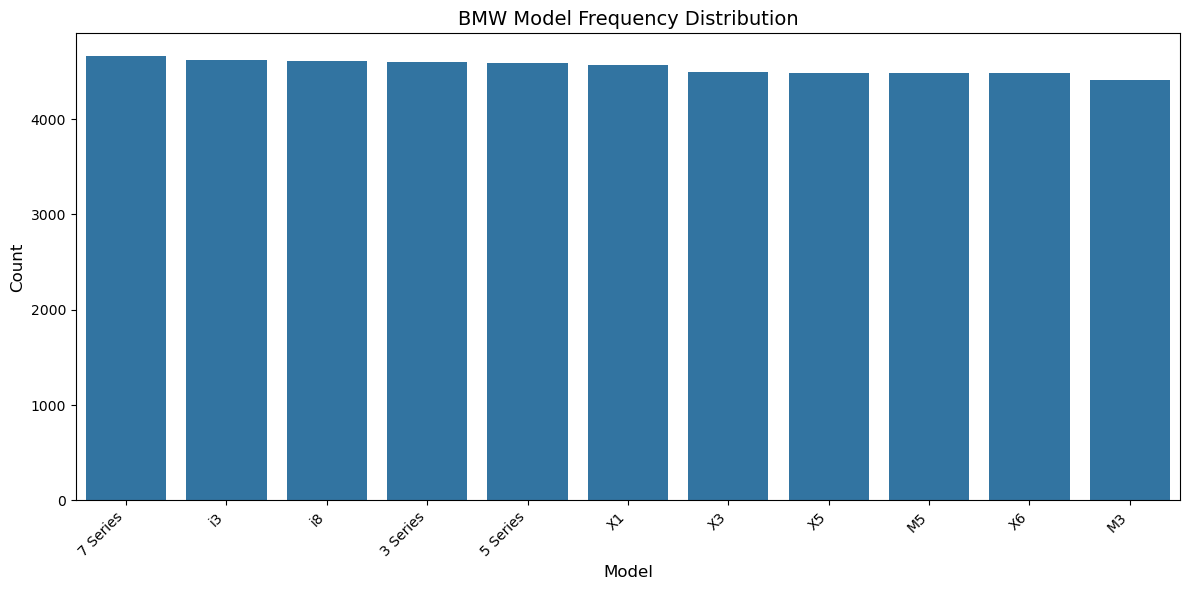

In [25]:
# --- 9. Categorical bar plots to inspect frequency distribution (Using 'Model')
plt.figure(figsize=(12, 6))
# Get value counts for better ordering
model_counts = df['Model'].value_counts()
sns.barplot(x=model_counts.index, y=model_counts.values)
plt.title('BMW Model Frequency Distribution', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("model_frequency_bar_plot.png")
print("Saved: model_frequency_bar_plot.png")

Saved: numeric_distribution_analysis.png


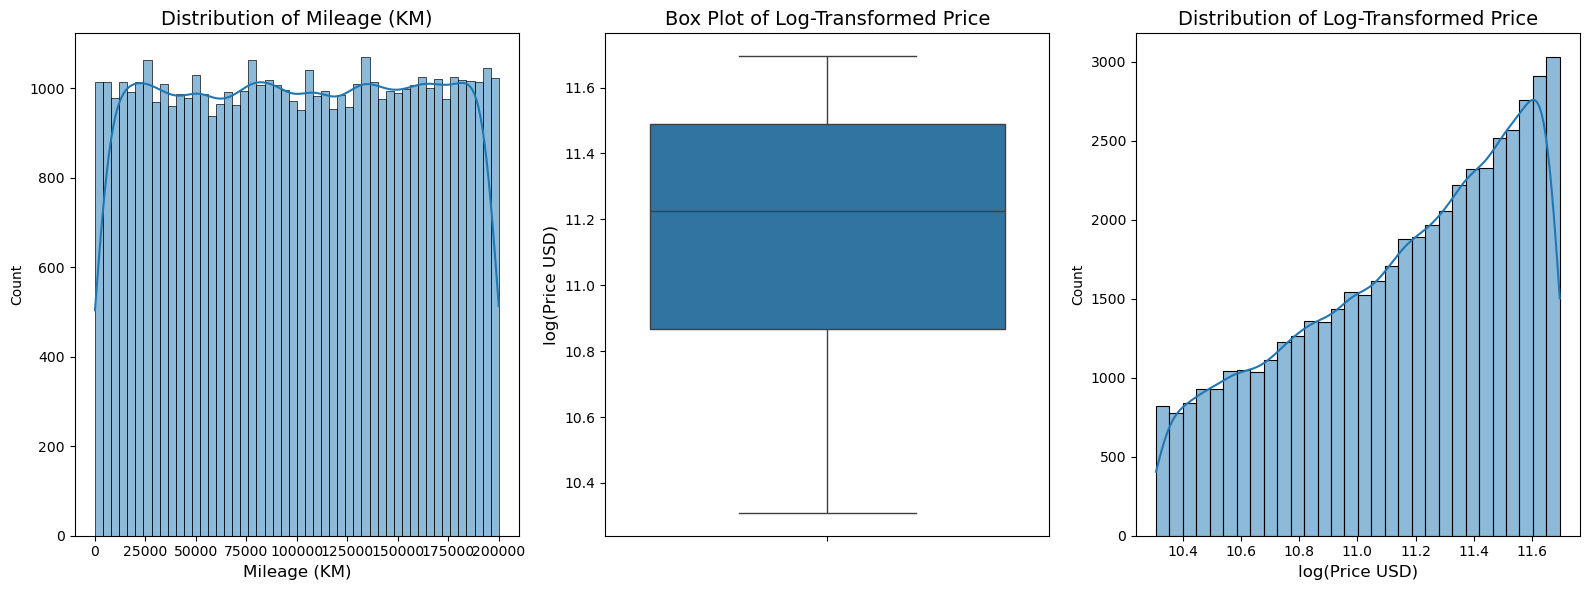

In [28]:
# Assuming imports are already done (pd, plt, sns)

# --- 5 & 6. Histograms, KDE plots for Mileage, and Boxplot/KDE for log_Price_USD (outlier treatment confirmation)
plt.figure(figsize=(16, 6))

# Subplot 1: Distribution of Mileage_KM
plt.subplot(1, 3, 1)
sns.histplot(df['Mileage_KM'], kde=True, bins=50)
plt.title('Distribution of Mileage (KM)', fontsize=14)
plt.xlabel('Mileage (KM)', fontsize=12)

# Subplot 2: Boxplot for log_Price_USD
plt.subplot(1, 3, 2)
sns.boxplot(y=df['log_Price_USD'])
plt.title('Box Plot of Log-Transformed Price', fontsize=14)
plt.ylabel('log(Price USD)', fontsize=12)

# Subplot 3: Distribution of log_Price_USD
plt.subplot(1, 3, 3)
sns.histplot(df['log_Price_USD'], kde=True, bins=30)
plt.title('Distribution of Log-Transformed Price', fontsize=14)
plt.xlabel('log(Price USD)', fontsize=12)

plt.tight_layout()
plt.savefig("numeric_distribution_analysis.png")
print("Saved: numeric_distribution_analysis.png")

Saved: correlation_heatmap.png


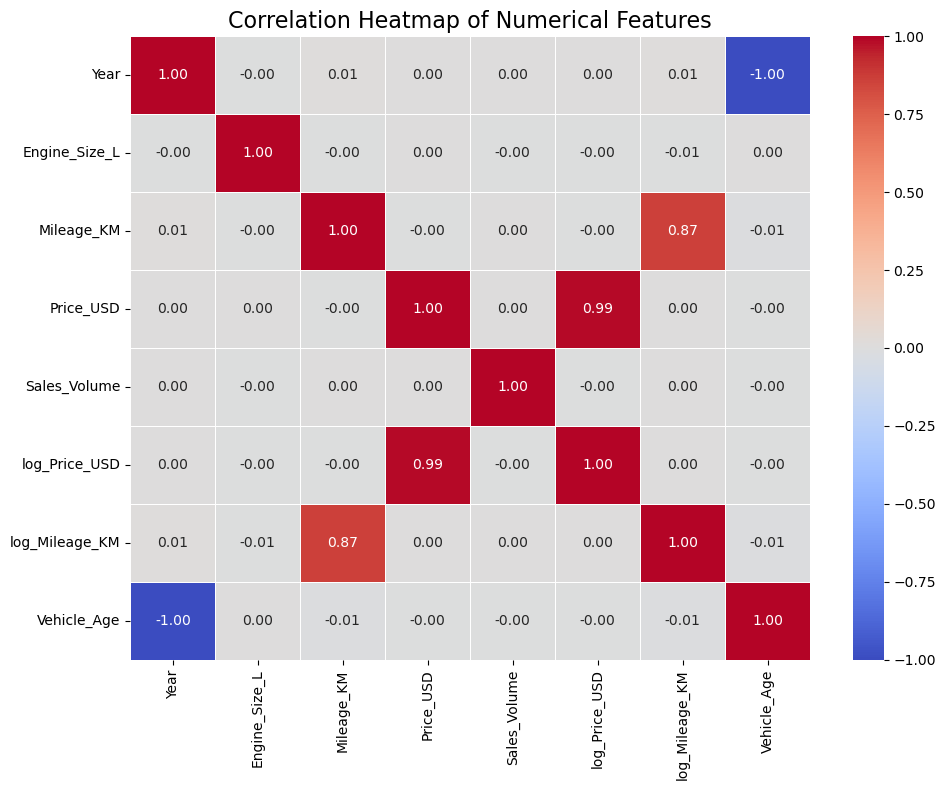

In [29]:
# --- 7. Correlation heatmap to find relationships.
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Saved: correlation_heatmap.png")

Saved: key_numeric_pairplot.png


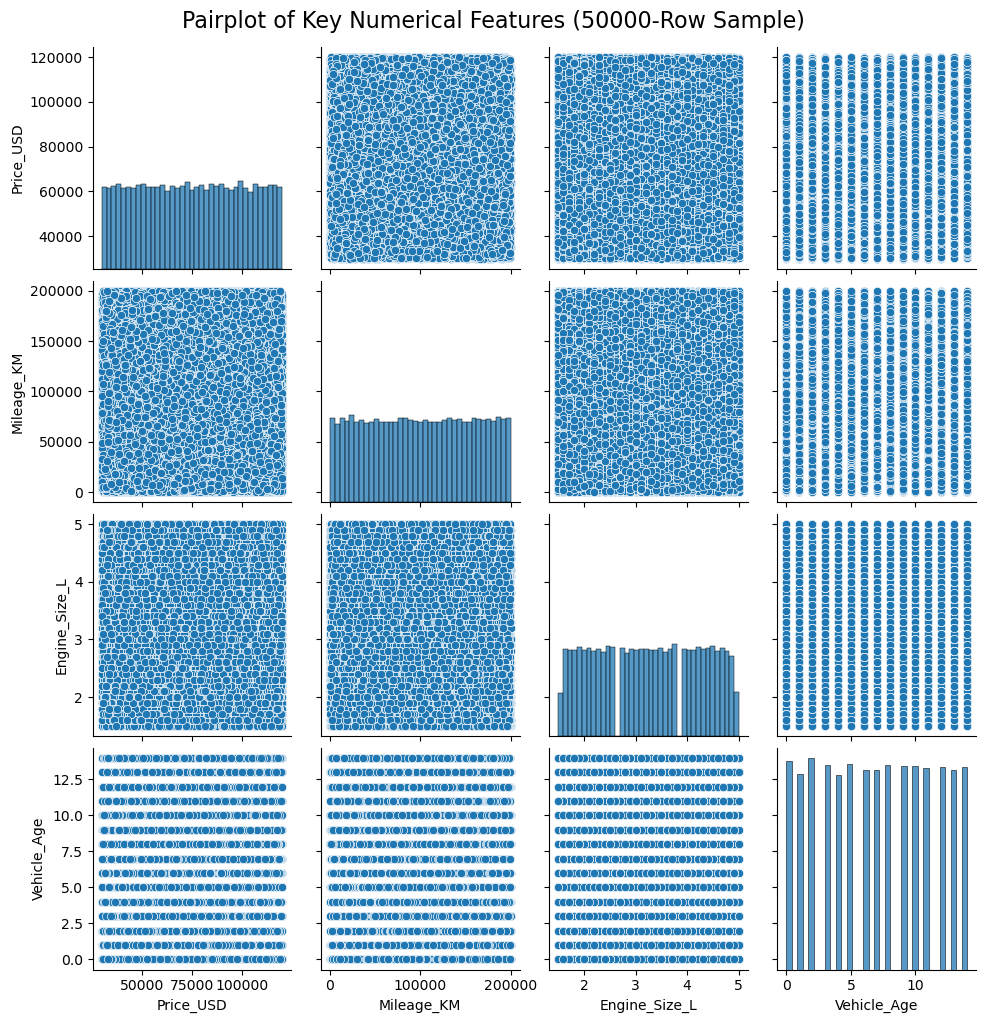

In [33]:
# Assuming imports are already done (pd, plt, sns)

# --- 8. Pairplot sample to see numeric correlations visually.
pairplot_cols = ['Price_USD', 'Mileage_KM', 'Engine_Size_L', 'Vehicle_Age']

# Use a small sample (50000 rows) for clearer visualization and faster rendering
df_sample = df.sample(n=50000, random_state=42)

sns.pairplot(df_sample[pairplot_cols])
plt.suptitle('Pairplot of Key Numerical Features (50000-Row Sample)', y=1.02, fontsize=16)
plt.savefig("key_numeric_pairplot.png")
print("Saved: key_numeric_pairplot.png")

Saved: price_vs_vehicle_age_regplot.png


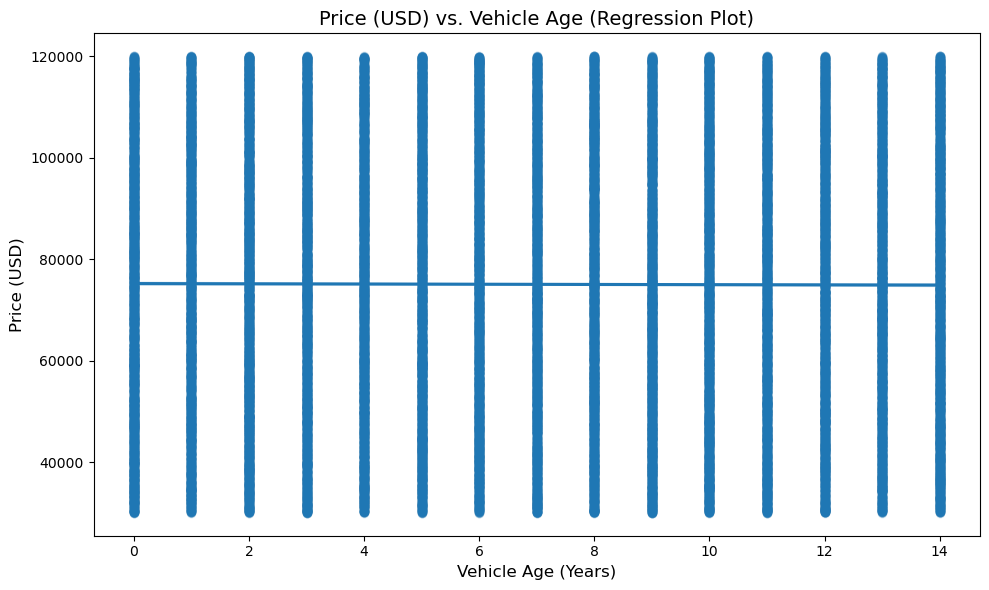

In [34]:
# --- 10. Engineered feature insight (Price_USD vs. Vehicle_Age)
# Use a regplot to show the relationship and a linear fit
plt.figure(figsize=(10, 6))
sns.regplot(x='Vehicle_Age', y='Price_USD', data=df, scatter_kws={'alpha':0.2})
plt.title('Price (USD) vs. Vehicle Age (Regression Plot)', fontsize=14)
plt.xlabel('Vehicle Age (Years)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.tight_layout()
plt.savefig("price_vs_vehicle_age_regplot.png")
print("Saved: price_vs_vehicle_age_regplot.png")

In [35]:
# ~~~ EDA workflow for BMW_cleaned_dataset.csv ~~~
# Save as run_eda_step3.ipynb or run in a Jupyter cell
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [36]:
# --- (2) Missing values report ---
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df) * 100).round(3)
missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)
print("\nMissing values (count + percent):")
display(missing_report)


Missing values (count + percent):


,missing_count,missing_percent
Model,0,0.0
Year,0,0.0
Region,0,0.0
Color,0,0.0
Fuel_Type,0,0.0
Transmission,0,0.0
Engine_Size_L,0,0.0
Mileage_KM,0,0.0
Price_USD,0,0.0
Sales_Volume,0,0.0


In [39]:
# Quick strategy hint:
# - If a column has >30% missing consider dropping or carefully imputing.
# - For categorical columns, consider 'Missing' as a valid category if meaningful.

# --- (3) Numeric summary + percentiles (include extreme percentiles) ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", num_cols)

# Describe with extra percentiles
percentiles = [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
desc = df[num_cols].describe(percentiles=percentiles).T
display(desc)

# For identifying outliers numerically also compute IQR and Z-scores
iqr = desc['75%'] - desc['25%']
outlier_thresholds = pd.DataFrame({
    "25%": desc['25%'],
    "75%": desc['75%'],
    "IQR": iqr,
    "lower_fence": desc['25%'] - 1.5*iqr,
    "upper_fence": desc['75%'] + 1.5*iqr
})
display(outlier_thresholds)



Numeric columns: ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume', 'log_Price_USD', 'log_Mileage_KM', 'Vehicle_Age']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Year,50000.0,2017.015700,4.324459,2010.000000,2010.000000,2010.000000,2013.000000,2017.000000,2021.000000,2024.000000,2024.000000,2024.000000
Engine_Size_L,50000.0,3.247180,1.009078,1.500000,1.500000,1.700000,2.400000,3.200000,4.100000,4.800000,5.000000,5.000000
Mileage_KM,50000.0,100307.203140,57941.509344,3.000000,1947.920000,10013.700000,50178.000000,100388.500000,150630.250000,190219.800000,198047.010000,199996.000000
Price_USD,50000.0,75034.600900,25998.248882,30000.000000,30840.990000,34574.000000,52434.750000,75011.500000,97628.250000,115530.050000,119134.000000,119998.000000
Sales_Volume,50000.0,5067.514680,2856.767125,100.000000,204.000000,597.000000,2588.000000,5087.000000,7537.250000,9510.000000,9897.000000,9999.000000
log_Price_USD,50000.0,11.157792,0.382002,10.308986,10.336632,10.450886,10.867344,11.225410,11.488932,11.657295,11.688013,11.695239
log_Mileage_KM,50000.0,11.207500,1.002797,1.386294,7.575031,9.211809,10.823352,11.516813,11.922590,12.155941,12.196265,12.206058
Vehicle_Age,50000.0,6.984300,4.324459,0.000000,0.000000,0.000000,3.000000,7.000000,11.000000,14.000000,14.000000,14.000000


,25%,75%,IQR,lower_fence,upper_fence
Year,2013.000000,2021.000000,8.000000,2001.000000,2033.000000
Engine_Size_L,2.400000,4.100000,1.700000,-0.150000,6.650000
Mileage_KM,50178.000000,150630.250000,100452.250000,-100500.375000,301308.625000
Price_USD,52434.750000,97628.250000,45193.500000,-15355.500000,165418.500000
Sales_Volume,2588.000000,7537.250000,4949.250000,-4835.875000,14961.125000
log_Price_USD,10.867344,11.488932,0.621589,9.934961,12.421315
log_Mileage_KM,10.823352,11.922590,1.099238,9.174495,13.571447
Vehicle_Age,3.000000,11.000000,8.000000,-9.000000,23.000000


In [40]:
# --- (4) Categorical summaries ---
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_summaries = {}
print("\nCategorical columns:", cat_cols)
for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    cat_summaries[c] = vc
    print(f"\n== {c} (top 20) ==")
    display(vc.head(20))


Categorical columns: ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']

== Model (top 20) ==


Model
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413
Name: count, dtype: int64


== Region (top 20) ==


Region
Asia             8454
Middle East      8373
North America    8335
Europe           8334
Africa           8253
South America    8251
Name: count, dtype: int64


== Color (top 20) ==


...

Fuel_Type
Hybrid      12716
Petrol      12550
Electric    12471
Diesel      12263
Name: count, dtype: int64


== Transmission (top 20) ==


Transmission
Manual       25154
Automatic    24846
Name: count, dtype: int64


== Sales_Classification (top 20) ==


Sales_Classification
Low     34754
High    15246
Name: count, dtype: int64

NameError: name 'OUTPUT_DIR' is not defined

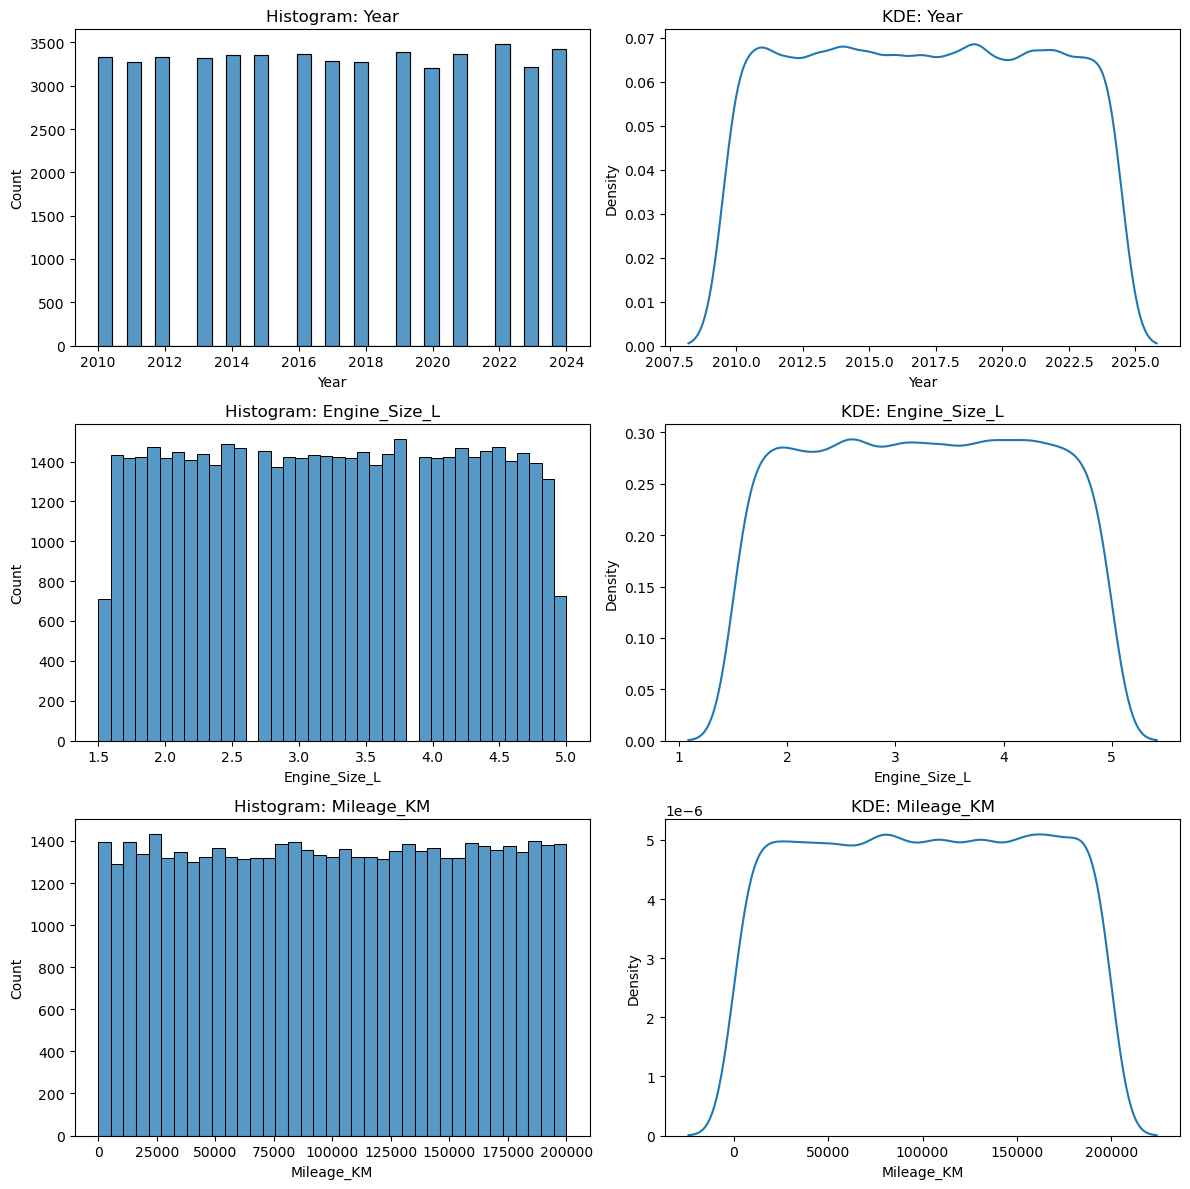

In [41]:
# --- (5) Histograms & KDE plots for numeric distributions ---
# We'll save plots to OUTPUT_DIR. For many numeric cols, create multi-page like files.
num_plots = len(num_cols)
cols_per_fig = 3
for i in range(0, num_plots, cols_per_fig):
    subset = num_cols[i:i+cols_per_fig]
    fig, axes = plt.subplots(len(subset), 2, figsize=(12, 4*len(subset)))
    for j, col in enumerate(subset):
        ax_hist = axes[j,0] if len(subset)>1 else axes[0]
        ax_kde = axes[j,1] if len(subset)>1 else axes[1]
        # histogram (use log scale when extremely skewed)
        sns.histplot(df[col].dropna(), kde=False, ax=ax_hist)
        ax_hist.set_title(f"Histogram: {col}")
        # KDE (on a sample if too large)
        sample = df[col].dropna()
        if len(sample) > 20000:
            sample = sample.sample(20000, random_state=42)
        try:
            sns.kdeplot(sample, ax=ax_kde)
            ax_kde.set_title(f"KDE: {col}")
        except Exception as e:
            ax_kde.text(0.5, 0.5, f"KDE failed: {e}", ha='center')
    plt.tight_layout()
    fig_path = os.path.join(OUTPUT_DIR, f"hist_kde_{i//cols_per_fig+1}.png")
    fig.savefig(fig_path, dpi=150)
    plt.close(fig)
    print("Saved:", fig_path)

NameError: name 'OUTPUT_DIR' is not defined

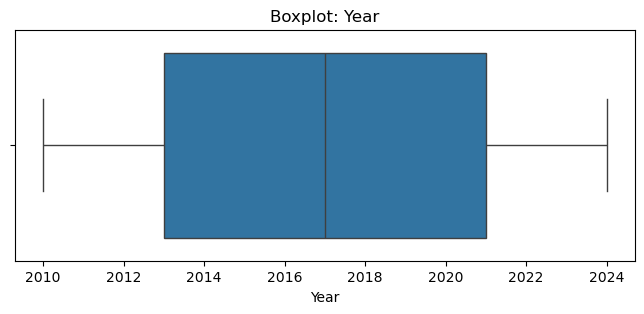

In [42]:
# --- (6) Boxplots to visually confirm outlier treatment ---
# Boxplots per numeric column (plot individually)
for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 3))
    sns.boxplot(x=df[col].dropna(), ax=ax)
    ax.set_title(f"Boxplot: {col}")
    fig_path = os.path.join(OUTPUT_DIR, f"boxplot_{col}.png")
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print("Saved:", fig_path)

NameError: name 'OUTPUT_DIR' is not defined

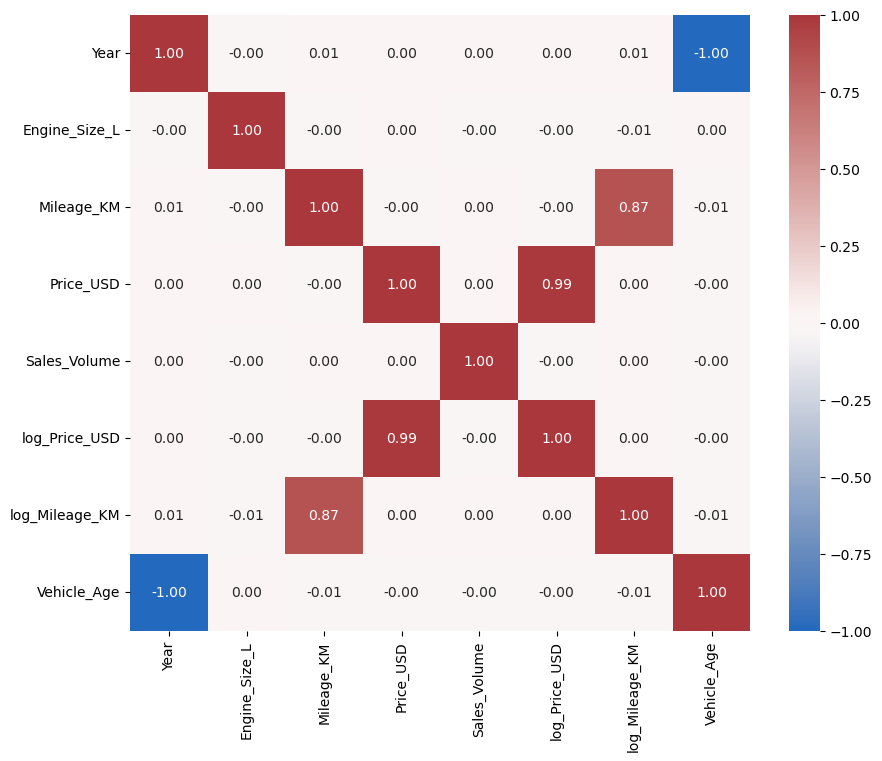

In [43]:
# --- (7) Correlation heatmap to find relationships ---
# We'll compute Pearson correlation for numeric columns
if len(num_cols) >= 2:
    corr = df[num_cols].corr(method='pearson')
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    heatmap_path = os.path.join(OUTPUT_DIR, "correlation_heatmap.png")
    plt.title("Pearson Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(heatmap_path, dpi=150)
    plt.close()
    print("Saved:", heatmap_path)
else:
    print("Not enough numeric columns for correlation heatmap.")

NameError: name 'OUTPUT_DIR' is not defined

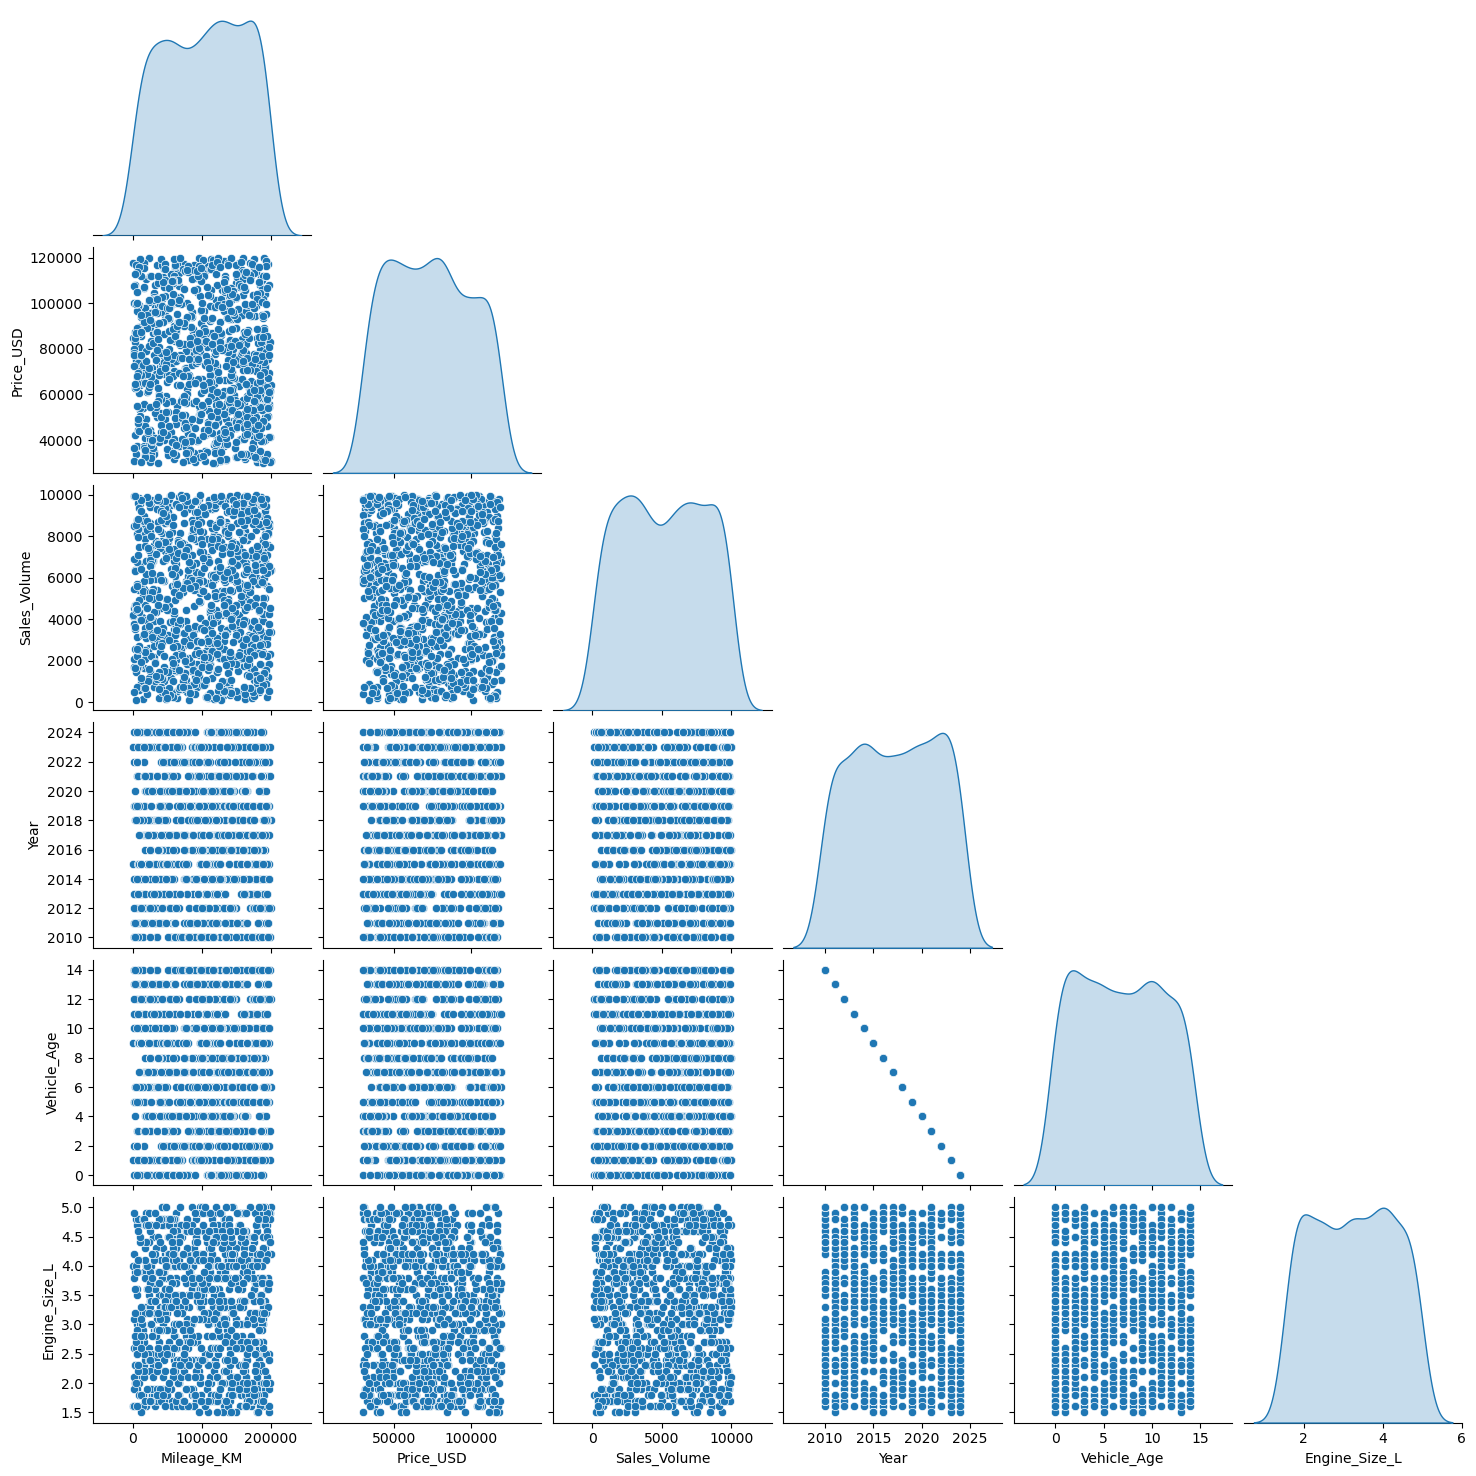

In [44]:
# --- (8) Pairplot sample to see numeric correlations visually ---
# Use a sample (max 1000 rows) to keep it responsive
pairplot_sample_size = 1000
pairplot_sample = df[num_cols].dropna().sample(n=min(pairplot_sample_size, len(df)), random_state=42)
if len(num_cols) <= 6:
    g = sns.pairplot(pairplot_sample, diag_kind='kde', corner=True)
    pairplot_path = os.path.join(OUTPUT_DIR, "pairplot.png")
    g.fig.suptitle("Pairplot (sample)", y=1.02)
    g.savefig(pairplot_path, dpi=150)
    plt.close()
    print("Saved:", pairplot_path)
else:
    # pick the most relevant numeric columns (top 6 by variance)
    variances = df[num_cols].var().sort_values(ascending=False)
    top6 = variances.index[:6].tolist()
    sample = df[top6].dropna().sample(n=min(pairplot_sample_size, len(df)), random_state=42)
    g = sns.pairplot(sample, diag_kind='kde', corner=True)
    pairplot_path = os.path.join(OUTPUT_DIR, "pairplot_top6.png")
    g.fig.suptitle("Pairplot (top6 by variance)", y=1.02)
    g.savefig(pairplot_path, dpi=150)
    plt.close()
    print("Saved:", pairplot_path)


NameError: name 'OUTPUT_DIR' is not defined

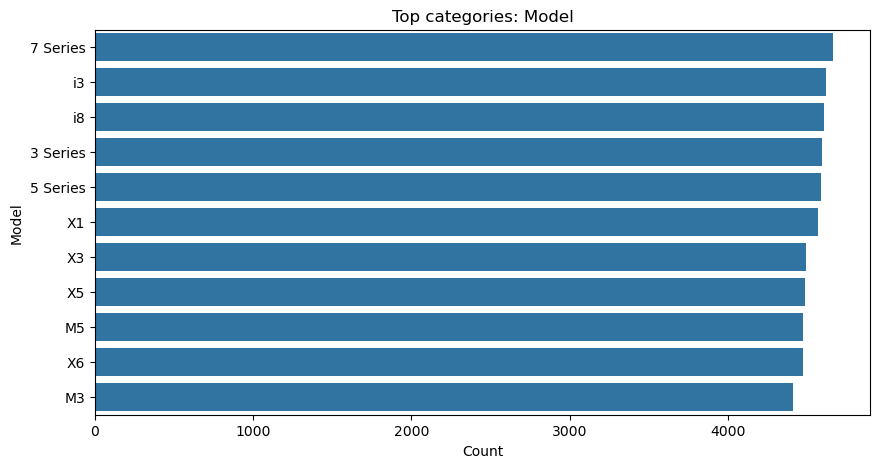

In [45]:
# --- (9) Categorical bar plots to inspect frequency distribution ---
# For each categorical column, plot top 20 categories
for c in cat_cols:
    vc = df[c].value_counts(dropna=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=vc.values, y=vc.index, orient='h', ax=ax)
    ax.set_title(f"Top categories: {c}")
    ax.set_xlabel("Count")
    fig_path = os.path.join(OUTPUT_DIR, f"catbar_{c}.png")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150)
    plt.close(fig)
    print("Saved:", fig_path)

In [46]:
# --- (10) Engineered feature insight ---
# Create a few features that often help in car sales analysis:
# - Age of car (using analysis year 2025)
ANALYSIS_YEAR = 2025
if 'Year' in df.columns:
    df['Age'] = ANALYSIS_YEAR - df['Year']
    print("\nCreated feature: Age (ANALYSIS_YEAR - Year). Sample:")
    display(df[['Year','Age']].head())
else:
    print("No 'Year' column found; skipping 'Age' feature.")

# - Price per km
if ('Price_USD' in df.columns) and ('Mileage_KM' in df.columns):
    df['Price_per_km'] = df['Price_USD'] / (df['Mileage_KM'].replace(0, np.nan))
    df['Price_per_km'] = df['Price_per_km'].replace([np.inf, -np.inf], np.nan)
    print("\nCreated feature: Price_per_km. Sample stats:")
    display(df['Price_per_km'].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))
else:
    print("Missing Price_USD or Mileage_KM; skipping Price_per_km feature.")

# - Log price (helpful for skewed price)
if 'Price_USD' in df.columns:
    df['Log_Price'] = np.log1p(df['Price_USD'].clip(lower=0))
    print("\nCreated feature: Log_Price. Sample stats:")
    display(df['Log_Price'].describe())
else:
    print("No Price_USD column for Log_Price.")

# - Engine size buckets
if 'Engine_Size_L' in df.columns:
    bins = [0, 1.5, 2.0, 3.0, 4.0, 10]
    labels = ['<=1.5','1.5-2.0','2.0-3.0','3.0-4.0','>4.0']
    df['Engine_size_bucket'] = pd.cut(df['Engine_Size_L'], bins=bins, labels=labels, include_lowest=True)
    print("\nCreated feature: Engine_size_bucket. Value counts:")
    display(df['Engine_size_bucket'].value_counts(dropna=False))
else:
    print("No Engine_Size_L; skipping bucket.")

# - Mileage buckets
if 'Mileage_KM' in df.columns:
    miles_bins = [ -1, 20000, 50000, 100000, 200000, 1000000 ]
    labels = ['0-20k','20k-50k','50k-100k','100k-200k','200k+']
    df['Mileage_bucket'] = pd.cut(df['Mileage_KM'], bins=miles_bins, labels=labels)
    print("\nCreated feature: Mileage_bucket. Value counts:")
    display(df['Mileage_bucket'].value_counts(dropna=False))
else:
    print("No Mileage_KM; skipping mileage buckets.")

# Save the augmented dataframe (optional)
aug_path = os.path.join(OUTPUT_DIR, "BMW_eda_augmented.csv")
df.to_csv(aug_path, index=False)
print("\nSaved augmented dataset:", aug_path)

# Save a short summary report as text
report_lines = []
report_lines.append(f"Dataset shape: {df.shape}")
report_lines.append("Top missing columns:")
report_lines.extend([f"{idx}: {val['missing_count']} ({val['missing_percent']}%)" 
                     for idx, val in missing_report.reset_index().rename(columns={'index':'col'}).set_index('col').to_dict('index').items() if val['missing_count']>0][:10])
report_text = "\n".join(report_lines)
with open(os.path.join(OUTPUT_DIR, "eda_summary.txt"), "w") as f:
    f.write(report_text)
print("Saved EDA summary to:", os.path.join(OUTPUT_DIR, "eda_summary.txt"))

print("\nAll plots and the augmented dataset are in:", OUTPUT_DIR)
print("Review the saved plots and the augmented dataset; if anything looks off, you can adjust outlier thresholds or imputation strategies and re-run.")



Created feature: Age (ANALYSIS_YEAR - Year). Sample:


,Year,Age
0,2016,9
1,2013,12
2,2022,3
3,2024,1
4,2020,5



Created feature: Price_per_km. Sample stats:


count    50000.000000
mean         4.114126
std        145.390737
min          0.152637
1%           0.191133
5%           0.254417
50%          0.748950
95%          7.569010
99%         38.061693
max      31311.000000
Name: Price_per_km, dtype: float64


Created feature: Log_Price. Sample stats:


...


Created feature: Engine_size_bucket. Value counts:


Engine_size_bucket
3.0-4.0    14321
2.0-3.0    14294
>4.0       13515
1.5-2.0     7160
<=1.5        710
Name: count, dtype: int64


Created feature: Mileage_bucket. Value counts:


Mileage_bucket
100k-200k    25085
50k-100k     12456
20k-50k       7452
0-20k         5007
200k+            0
Name: count, dtype: int64

NameError: name 'OUTPUT_DIR' is not defined

In [51]:
# KPI analysis 
# BMW KPI ANALYSIS - CLEAN & ERROR-FREE VERSION
# Path updated for Windows local environment
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
INPUT_CSV = r"C:\Users\Administrateur\Desktop\JUPYTER\BMW_cleaned_dataset.csv"
OUTPUT_DIR = r"C:\Users\Administrateur\Desktop\JUPYTER\KPI_OUTPUTS"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_CSV)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (50000, 14)
      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  log_Price_USD  \
0      151748      98740          8300                 High      11.500256   
1      121671      79219          3428                  Low      11.279984   
2       10991     113265          6994                  Low      11.637494   
3       27255      60971          4047                  Low      11.018170   
4      122131      49898          3080                  Low      10.817756 

In [53]:
# Convert numeric columns
num_cols = ["Price_USD", "Mileage_KM", "Engine_Size_L", "Year", "Sales_Volume"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [54]:
# If Sales_Volume missing, assume 1
if "Sales_Volume" not in df.columns:
    df["Sales_Volume"] = 1

In [56]:
# 2. Compute Revenue Column
# ------------------------------------------------------------
df["Revenue"] = df["Price_USD"] * df["Sales_Volume"]

In [57]:
# 3. Global KPIs
# ------------------------------------------------------------
kpis = {
    "Total Rows": len(df),
    "Total Units Sold": df["Sales_Volume"].sum(),
    "Total Revenue": df["Revenue"].sum(),
    "Median Price": df["Price_USD"].median(),
    "Mean Price": df["Price_USD"].mean(),
    "Min Price": df["Price_USD"].min(),
    "Max Price": df["Price_USD"].max(),
}

print("\n===== GLOBAL KPIs =====")
for k, v in kpis.items():
    print(f"{k}: {v}")

pd.Series(kpis).to_csv(os.path.join(OUTPUT_DIR, "kpi_summary.csv"))


===== GLOBAL KPIs =====
Total Rows: 50000
Total Units Sold: 253375734
Total Revenue: 19012242534459
Median Price: 75011.5
Mean Price: 75034.6009
Min Price: 30000
Max Price: 119998


In [59]:
# 4. Revenue by Region
# ------------------------------------------------------------
if "Region" in df.columns:
    region_rev = df.groupby("Region").agg(
        Total_Units=("Sales_Volume", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Median_Price=("Price_USD", "median")
    ).sort_values("Total_Revenue", ascending=False)

    region_rev.to_csv(os.path.join(OUTPUT_DIR, "revenue_by_region.csv"))

    plt.figure(figsize=(10, 6))
    sns.barplot(x=region_rev.index, y=region_rev["Total_Revenue"])
    plt.title("Revenue by Region")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "revenue_by_region.png"))
    plt.close()


In [60]:
Top Models by Units Sold
# ------------------------------------------------------------
if "Model" in df.columns:
    model_sales = df.groupby("Model").agg(
        Total_Units=("Sales_Volume", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Median_Price=("Price_USD", "median")
    ).sort_values("Total_Units", ascending=False)

    model_sales.to_csv(os.path.join(OUTPUT_DIR, "top_models.csv"))

    plt.figure(figsize=(10, 12))
    sns.barplot(y=model_sales.index[:20], x=model_sales["Total_Units"][:20])
    plt.title("Top 20 Models by Units Sold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "top_models.png"))
    plt.close()


SyntaxError: invalid syntax (3042318620.py, line 1)

In [63]:
# 6. Price Distribution
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df["Price_USD"].dropna(), kde=True)
plt.title("Price Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "price_distribution.png"))
plt.close()

df["Price_USD"].describe(percentiles=[.01, .05, .5, .95, .99]).to_csv(
    os.path.join(OUTPUT_DIR, "price_distribution_stats.csv")
)

In [65]:
# 7. Price vs Age (if Year exists)
# ------------------------------------------------------------
if "Year" in df.columns:
    df["Age"] = 2025 - df["Year"]

    sample = df.dropna(subset=["Age", "Price_USD"]).sample(
        n=min(5000, len(df)), random_state=42
    )

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=sample, x="Age", y="Price_USD", alpha=0.4)
    sns.regplot(data=sample, x="Age", y="Price_USD", scatter=False, lowess=True)
    plt.title("Price vs Age")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "price_vs_age.png"))
    plt.close()

In [66]:
# 8. Price vs Mileage
# ------------------------------------------------------------
if "Mileage_KM" in df.columns:
    sample = df.dropna(subset=["Mileage_KM", "Price_USD"]).sample(
        n=min(5000, len(df)), random_state=42
    )

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=sample, x="Mileage_KM", y="Price_USD", alpha=0.4)
    sns.regplot(data=sample, x="Mileage_KM", y="Price_USD", scatter=False, lowess=True)
    plt.title("Price vs Mileage")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "price_vs_mileage.png"))
    plt.close()


In [67]:
# 9. Correlation Heatmap
# ------------------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap.png"))
plt.close()

In [68]:
# 10. Demand Score (Model Ranking)
# ------------------------------------------------------------
if "Model" in df.columns:
    df["Sales_Class_Num"] = df.get("Sales_Classification").map(
        {"High": 2, "Medium": 1, "Low": 0}
    ) if "Sales_Classification" in df.columns else 1

    df["Demand_Score"] = (
        0.7 * (df["Sales_Volume"] / df["Sales_Volume"].max()) +
        0.3 * (df["Sales_Class_Num"] / df["Sales_Class_Num"].max())
    )

    demand_model = df.groupby("Model")["Demand_Score"].mean().sort_values(ascending=False)
    demand_model.to_csv(os.path.join(OUTPUT_DIR, "demand_score_model.csv"))

print("\n\n================================================")
print("KPI ANALYSIS COMPLETE — Files saved to:")
print(OUTPUT_DIR)
print("================================================")



KPI ANALYSIS COMPLETE — Files saved to:
C:\Users\Administrateur\Desktop\JUPYTER\KPI_OUTPUTS
